<a href="https://colab.research.google.com/github/amr0ym/TM351-Data-Management-TMA/blob/main/Q2_Project_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Load dataset from GitHub (Raw URL)
url = "https://raw.githubusercontent.com/amr0ym/TM351-Data-Management-TMA/refs/heads/main/Airline%20Dataset%20Updated%20-%20v2.csv"
df = pd.read_csv(url)

In [2]:
# Define research variables
independent_var = "Airport Continent"
dependent_var = "Flight Status"

In [3]:
# Check basic structure
df[[independent_var, dependent_var]].head()

,Airport Continent,Flight Status
0,NAM,On Time
1,NAM,On Time
2,EU,On Time
3,NAM,Delayed
4,NAM,On Time


In [4]:
# Crosstab showing flight status distribution by continent
crosstab_table = pd.crosstab(
    df[independent_var],
    df[dependent_var]
)

crosstab_table

Flight Status,Cancelled,Delayed,On Time
Airport Continent,,,
AF,3657,3654,3719
AS,6235,6160,6242
EU,4095,4178,4062
NAM,10693,10696,10644
OC,4619,4634,4613
SAM,3643,3509,3566


In [5]:
# Perform Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(crosstab_table)

print("Chi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p_value)

Chi-Square Statistic: 5.6579925979593835
Degrees of Freedom: 10
P-value: 0.8431323616966917


In [6]:
# Pivot table (same idea, different presentation)
pivot_table = df.pivot_table(
    index=independent_var,
    columns=dependent_var,
    aggfunc='size',
    fill_value=0
)

pivot_table

Flight Status,Cancelled,Delayed,On Time
Airport Continent,,,
AF,3657,3654,3719
AS,6235,6160,6242
EU,4095,4178,4062
NAM,10693,10696,10644
OC,4619,4634,4613
SAM,3643,3509,3566


In [7]:
# Percentage comparison for categorical columns
for col in df.select_dtypes(include=['object']).columns:
    percentages = (df.groupby(col).size() / df[col].count()) * 100
    print(f"\nPercentage distribution for column: {col}")
    print(percentages.round(2))


Percentage distribution for column: Passenger ID
Passenger ID
002Gd9    0.0
00638T    0.0
006RvT    0.0
008AJe    0.0
00Ahsk    0.0
         ... 
zzmvXb    0.0
zzsIdD    0.0
zzt3WK    0.0
zzuv5J    0.0
zzy9KO    0.0
Length: 98619, dtype: float64

Percentage distribution for column: First Name
First Name
Aaren      0.01
Aarika     0.01
Aaron      0.01
Ab         0.01
Abagael    0.01
           ... 
Zorine     0.01
Zsa zsa    0.01
Zsazsa     0.01
Zulema     0.01
Zuzana     0.01
Length: 8437, dtype: float64

Percentage distribution for column: Last Name
Last Name
A'field          0.0
Aaron            0.0
Aarons           0.0
Aaronsohn        0.0
Aaronson         0.0
                ... 
le Keux          0.0
oldey            0.0
todor            0.0
von Grollmann    0.0
von Nassau       0.0
Length: 41658, dtype: float64

Percentage distribution for column: Gender
Gender
Female    49.71
Male      50.29
dtype: float64

Percentage distribution for column: Nationality
Nationality
Afghanistan 

<Figure size 1000x600 with 0 Axes>

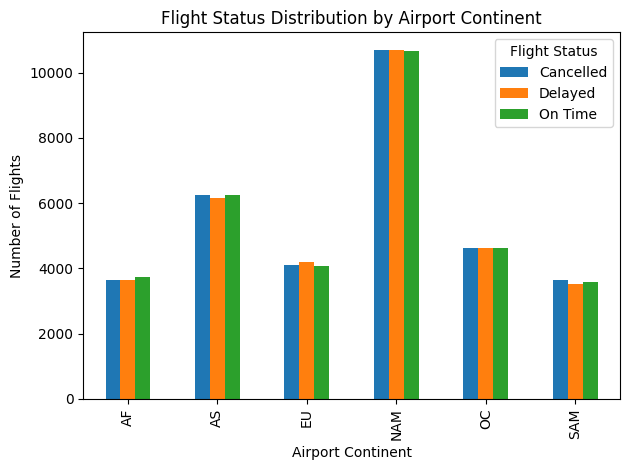

In [8]:
plt.figure(figsize=(10,6))
pivot_table.plot(kind='bar')
plt.title("Flight Status Distribution by Airport Continent")
plt.xlabel("Airport Continent")
plt.ylabel("Number of Flights")
plt.legend(title="Flight Status")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

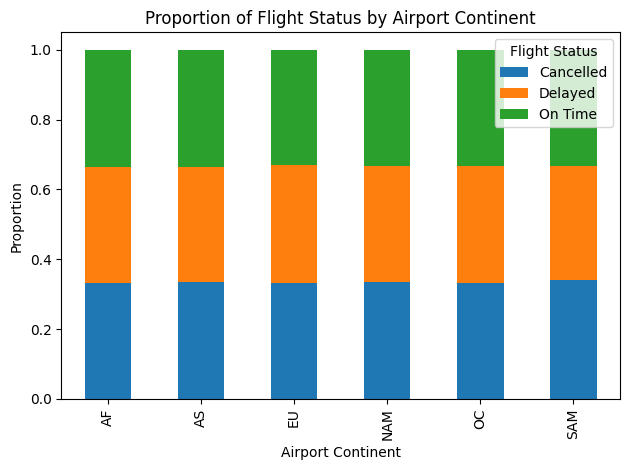

In [9]:
# Normalize data to show proportions
normalized_table = pivot_table.div(pivot_table.sum(axis=1), axis=0)

plt.figure(figsize=(10,6))
normalized_table.plot(kind='bar', stacked=True)
plt.title("Proportion of Flight Status by Airport Continent")
plt.xlabel("Airport Continent")
plt.ylabel("Proportion")
plt.legend(title="Flight Status")
plt.tight_layout()
plt.show()

In [10]:
# Check missing values (no imputation)
df[[independent_var, dependent_var]].isnull().sum()

,0
Airport Continent,0
Flight Status,0
